In [30]:
!pip install -q datasets transformers torch scikit-learn matplotlib seaborn

Chọn dữ liệu các bài đăng phân theo tầm 20 nhóm chủ đề:
`https://huggingface.co/datasets/SetFit/20_newsgroups`

Lấy 100% dữ liệu

Thêm chia train/ val / test với tỷ lệ 0.2


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from collections import Counter
import pandas as pd

# 1. Tải dữ liệu
print("Đang tải dữ liệu...")
dataset = load_dataset("SetFit/20_newsgroups")

Đang tải dữ liệu...


Repo card metadata block was not found. Setting CardData to empty.


In [41]:
print("\nThông tin tập dữ liệu:")
print(dataset)
print("\nCác cột trong tập train:", dataset['train'].column_names)

# Để thời gian chạy nhanh theo yêu cầu, ta lấy 10% dữ liệu để huấn luyện và đánh giá
sample_ratio = 1.0
train_full = dataset['train'].shuffle(seed=42).select(range(int(len(dataset['train']) * sample_ratio)))
test_data = dataset['test'].shuffle(seed=42).select(range(int(len(dataset['test']) * sample_ratio)))

# Chuyển đổi sang Pandas DataFrame để tương thích tốt hơn với sklearn
train_full_df = train_full.to_pandas()
test_data_df = test_data.to_pandas()

# Chia tập train_full thành Train và Validation (Tỉ lệ 80/20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_full_df['text'], train_full_df['label'], test_size=0.2, random_state=42
)
test_texts, test_labels = test_data_df['text'], test_data_df['label']

print(f"\nSố lượng mẫu - Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")


Thông tin tập dữ liệu:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 11314
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7532
    })
})

Các cột trong tập train: ['text', 'label', 'label_text']

Số lượng mẫu - Train: 9051, Val: 2263, Test: 7532


In [43]:
label_counts = Counter(train_labels)
print("\nThống kê số lượng mẫu theo từng nhãn (Tập Train):")
for label, count in sorted(label_counts.items()):
    print(f"Nhãn {label}: {count} mẫu")

print("\nVí dụ dữ liệu:")
for i in range(2):
    print(f"--- Mẫu {i+1} (Nhãn: {train_labels.iloc[i]}) ---")
    print(train_texts.iloc[i][:200] + "...\n")


Thống kê số lượng mẫu theo từng nhãn (Tập Train):
Nhãn 0: 374 mẫu
Nhãn 1: 447 mẫu
Nhãn 2: 478 mẫu
Nhãn 3: 478 mẫu
Nhãn 4: 472 mẫu
Nhãn 5: 467 mẫu
Nhãn 6: 464 mẫu
Nhãn 7: 485 mẫu
Nhãn 8: 488 mẫu
Nhãn 9: 482 mẫu
Nhãn 10: 464 mẫu
Nhãn 11: 475 mẫu
Nhãn 12: 473 mẫu
Nhãn 13: 486 mẫu
Nhãn 14: 469 mẫu
Nhãn 15: 486 mẫu
Nhãn 16: 428 mẫu
Nhãn 17: 458 mẫu
Nhãn 18: 375 mẫu
Nhãn 19: 302 mẫu

Ví dụ dữ liệu:
--- Mẫu 1 (Nhãn: 3) ---
Have anybody succeded in converting a atari monomchrome monitor into a
mono VGA monitor. If so please let me know exactly how you did and what
graphics card you used.

	/Thanx...

--- Mẫu 2 (Nhãn: 11) ---

[...]>
[...]>

If the data isn't there when the warrant comes, you effectively have
secure crypto.  If secret backups are kept...then you effectively have
no crypto.  Thus, this poster is essentialy ...



Tiền xử lý dữ liệu (Tokenization, Build Vocabulary)

In [44]:
import nltk
from nltk.corpus import stopwords

# Tải danh sách stopwords tiếng Anh
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [45]:
# Hàm tiền xử lý văn bản cơ bản
def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) # Chỉ giữ lại chữ và số
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return text.split()

# Xây dựng từ điển (Vocabulary) từ tập Train
print("Đang xây dựng từ điển...")
vocab_counts = Counter()
for text in train_texts:
    vocab_counts.update(tokenize(text))

# Giới hạn số lượng từ trong từ điển, giữ lại các từ xuất hiện nhiều
MAX_VOCAB_SIZE = 10000
vocab = {word: i+2 for i, (word, _) in enumerate(vocab_counts.most_common(MAX_VOCAB_SIZE))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

# Tăng max_len lên 300 để bắt được nhiều ngữ cảnh hơn
def text_to_indices(text, max_len=300):
    tokens = tokenize(text)
    indices = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    # Cắt ngắn nếu dài hơn max_len
    if len(indices) > max_len:
        indices = indices[:max_len]
    return indices

class TextDataset(Dataset):
    def __init__(self, texts, labels, max_len=300):
        self.x = [torch.tensor(text_to_indices(t, max_len), dtype=torch.long) for t in texts]
        self.y = torch.tensor(labels.to_list(), dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

def collate_fn(batch):
    xs, ys = zip(*batch)
    lengths = torch.tensor([len(x) for x in xs])
    # Padding các sequence cho bằng nhau trong cùng một batch
    xs_padded = pad_sequence(xs, batch_first=True, padding_value=0)
    return xs_padded, torch.stack(ys), lengths

# Tạo DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(TextDataset(train_texts, train_labels), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(TextDataset(val_texts, val_labels), batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(TextDataset(test_texts, test_labels), batch_size=BATCH_SIZE, collate_fn=collate_fn)

Đang xây dựng từ điển...


Mô hình RNN/ LSTM / GRU với tùy chỉnh Pooling

In [46]:
class TextClassificationModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 model_type='LSTM', num_layers=4, bidirectional=True, pooling='mean', dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout) # Thêm Dropout
        self.model_type = model_type
        self.pooling = pooling
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim

        rnn_args = {
            'input_size': embed_dim,
            'hidden_size': hidden_dim,
            'num_layers': num_layers,
            'bidirectional': bidirectional,
            'batch_first': True,
            'dropout': dropout if num_layers > 1 else 0 # Dropout nội bộ cho RNN
        }

        if model_type == 'RNN':
            self.rnn = nn.RNN(**rnn_args)
        elif model_type == 'LSTM':
            self.rnn = nn.LSTM(**rnn_args)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(**rnn_args)

        rnn_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

        if pooling == 'attention':
            self.attention = nn.Linear(rnn_out_dim, 1)

        self.fc = nn.Linear(rnn_out_dim, num_classes)

    def forward(self, x, lengths):
        # Áp dụng dropout ngay sau lớp nhúng từ
        embedded = self.dropout(self.embedding(x))

        if self.model_type == 'LSTM':
            out, (hidden, cell) = self.rnn(embedded)
        else:
            out, hidden = self.rnn(embedded)

        if self.pooling == 'last':
            if self.bidirectional:
                out_pool = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
            else:
                out_pool = hidden[-1,:,:]
        elif self.pooling == 'mean':
            out_pool = torch.mean(out, dim=1)
        elif self.pooling == 'max':
            out_pool, _ = torch.max(out, dim=1)
        elif self.pooling == 'attention':
            attn_weights = torch.softmax(self.attention(out), dim=1)
            out_pool = torch.sum(attn_weights * out, dim=1)

        # Áp dụng dropout một lần nữa trước lớp phân loại
        logits = self.fc(self.dropout(out_pool))
        return logits

Train và Evaluate

In [48]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, patience=4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # Bổ sung L2 Regularization (weight_decay) để giảm overfitting
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # Thêm Scheduler: Giảm LR đi một nửa nếu Val Acc không tăng sau 2 epoch
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    best_val_acc = 0.0
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for xs, ys, lengths in train_loader:
            xs, ys = xs.to(device), ys.to(device)
            optimizer.zero_grad()
            logits = model(xs, lengths)
            loss = criterion(logits, ys)
            loss.backward()

            # Clip gradient để tránh nổ gradient (phổ biến trong RNN)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for xs, ys, lengths in val_loader:
                xs, ys = xs.to(device), ys.to(device)
                logits = model(xs, lengths)
                loss = criterion(logits, ys)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                correct += (preds == ys).sum().item()
                total += ys.size(0)

        val_acc_current = correct/total
        history['train_loss'].append(train_loss/len(train_loader))
        history['val_loss'].append(val_loss/len(val_loader))
        history['val_acc'].append(val_acc_current)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc_current:.4f}")

        # Cập nhật Scheduler
        scheduler.step(val_acc_current)

        # Early Stopping
        if val_acc_current > best_val_acc:
            best_val_acc = val_acc_current
            epochs_no_improve = 0
            # Có thể chèn code lưu model tốt nhất tại đây: torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f">>> Early stopping được kích hoạt tại epoch {epoch+1}. Dừng huấn luyện.")
                break

    return history

# def evaluate_model(model, test_loader):
#     # (Đoạn này giữ nguyên như cũ của bạn)
#     model.eval()
#     all_preds = []
#     all_targets = []
#     with torch.no_grad():
#         for xs, ys, lengths in test_loader:
#             xs, ys = xs.to(device), ys.to(device)
#             logits = model(xs, lengths)
#             preds = torch.argmax(logits, dim=1)
#             all_preds.extend(preds.cpu().numpy())
#             all_targets.extend(ys.cpu().numpy())

#     acc = accuracy_score(all_targets, all_preds)
#     prec = precision_score(all_targets, all_preds, average='macro', zero_division=0)
#     rec = recall_score(all_targets, all_preds, average='macro', zero_division=0)
#     f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

#     print(f"Test Accuracy : {acc:.4f}")
#     print(f"Test Precision: {prec:.4f}")
#     print(f"Test Recall   : {rec:.4f}")
#     print(f"Test F1-Score : {f1:.4f}")
#     return acc, prec, rec, f1
#     # TRẢ VỀ THÊM CẢ TARGETS VÀ PREDS ĐỂ VẼ CONFUSION MATRIX
#     return metrics, all_targets, all_preds

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xs, ys, lengths in test_loader:
            xs, ys = xs.to(device), ys.to(device)
            logits = model(xs, lengths)
            preds = torch.argmax(logits, dim=1)

            # Chuyển đổi tensor về numpy array và đưa vào list
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(ys.cpu().numpy())

    # Tính toán các metrics
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

    # In kết quả ra màn hình
    print(f"Test Accuracy : {acc:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall   : {rec:.4f}")
    print(f"Test F1-Score : {f1:.4f}")

    # Quan trọng: Trả về chính xác 3 biến để phục vụ việc lưu lịch sử và vẽ Confusion Matrix
    return acc, all_targets, all_preds

Chạy thử nghiệm và Vẽ Learning Curve so sánh các cấu hình


Đang huấn luyện: Basic RNN
Epoch 1/20 | Train Loss: 3.0036 | Val Loss: 2.9928 | Val Acc: 0.0588
Epoch 2/20 | Train Loss: 2.9842 | Val Loss: 2.9912 | Val Acc: 0.0597
Epoch 3/20 | Train Loss: 2.9700 | Val Loss: 2.9931 | Val Acc: 0.0561
Epoch 4/20 | Train Loss: 2.9579 | Val Loss: 2.9915 | Val Acc: 0.0566
Epoch 5/20 | Train Loss: 2.9494 | Val Loss: 2.9909 | Val Acc: 0.0588
>>> Early stopping được kích hoạt tại epoch 5. Dừng huấn luyện.

--- Đánh giá trên tập Test ---
Test Accuracy : 0.0641
Test Precision: 0.1064
Test Recall   : 0.0610
Test F1-Score : 0.0223

Đang huấn luyện: LSTM + Bidir
Epoch 1/20 | Train Loss: 2.9415 | Val Loss: 2.9049 | Val Acc: 0.1087
Epoch 2/20 | Train Loss: 2.7773 | Val Loss: 2.7224 | Val Acc: 0.1255
Epoch 3/20 | Train Loss: 2.6228 | Val Loss: 2.5678 | Val Acc: 0.1582
Epoch 4/20 | Train Loss: 2.5324 | Val Loss: 2.5166 | Val Acc: 0.1653
Epoch 5/20 | Train Loss: 2.4015 | Val Loss: 2.4874 | Val Acc: 0.1723
Epoch 6/20 | Train Loss: 2.2763 | Val Loss: 2.4044 | Val Acc: 0

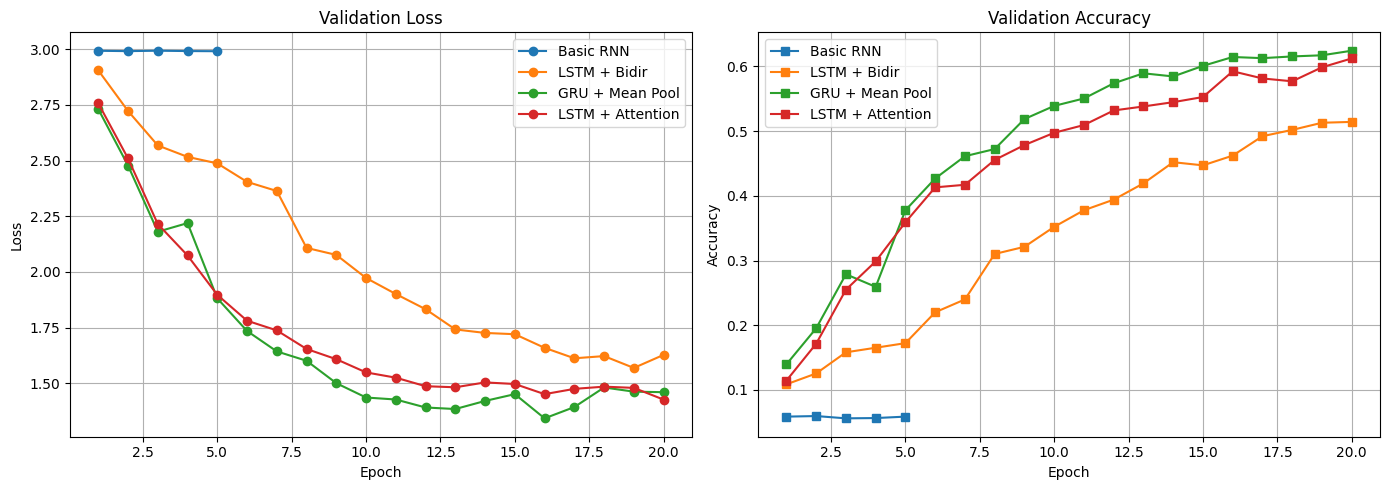

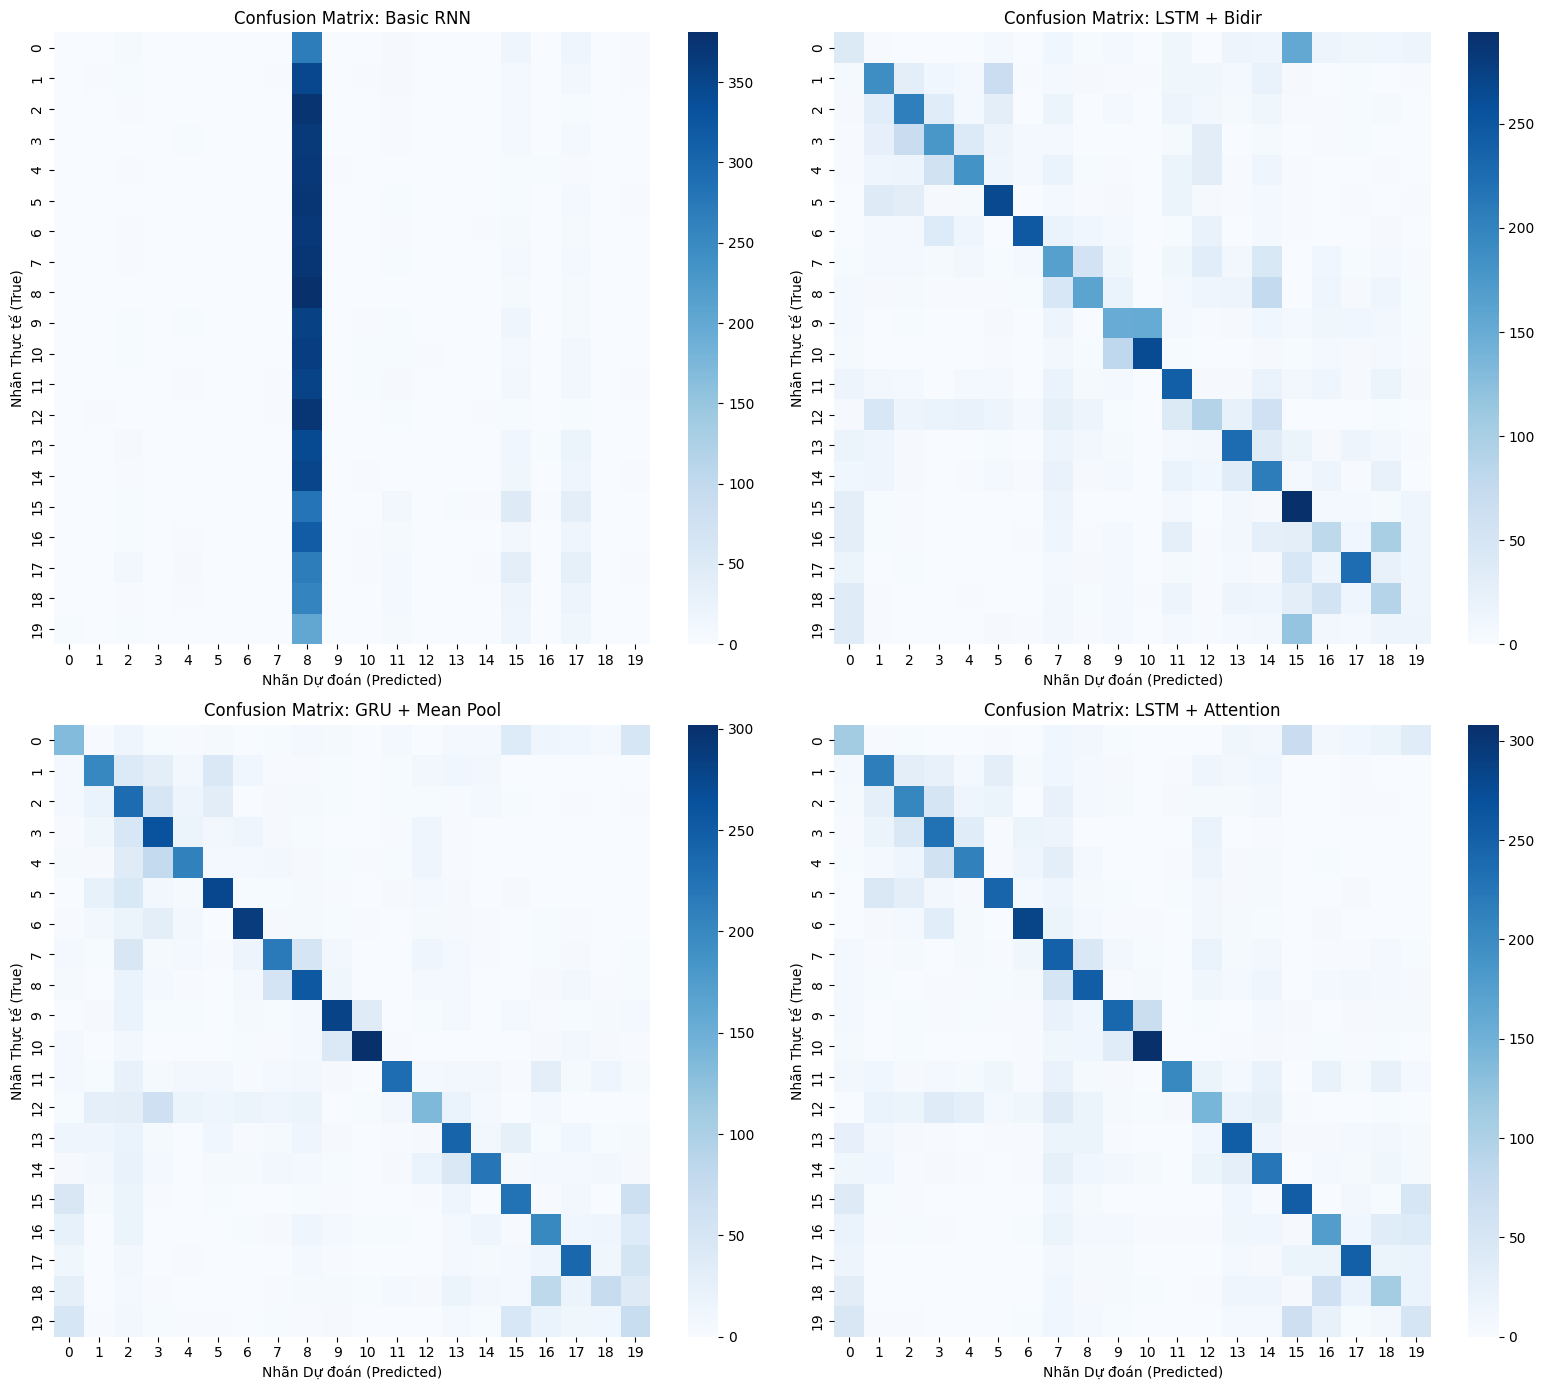


BÁO CÁO CHI TIẾT ĐIỂM LỖI TỪNG LỚP: LSTM + Attention
              precision    recall  f1-score   support

           0       0.30      0.35      0.33       319
           1       0.55      0.56      0.55       389
           2       0.54      0.52      0.53       394
           3       0.49      0.59      0.53       392
           4       0.64      0.55      0.59       385
           5       0.73      0.62      0.67       395
           6       0.75      0.73      0.74       390
           7       0.39      0.63      0.49       396
           8       0.56      0.64      0.60       398
           9       0.69      0.61      0.65       397
          10       0.75      0.77      0.76       399
          11       0.89      0.51      0.65       396
          12       0.47      0.37      0.41       393
          13       0.60      0.64      0.62       396
          14       0.55      0.57      0.56       394
          15       0.58      0.64      0.61       398
          16       0.51    

In [50]:
VOCAB_SIZE = len(vocab)
EMBED_DIM = 128
NUM_CLASSES = 20
EPOCHS = 20

# Cải tiến: Thêm chiều sâu (layers) cho các cấu hình tốt
configs = [
    {'name': 'Basic RNN',        'type': 'RNN',  'hidden': 64,  'bidir': False, 'pool': 'last', 'layers': 1},
    {'name': 'LSTM + Bidir',     'type': 'LSTM', 'hidden': 128, 'bidir': True,  'pool': 'last', 'layers': 2},
    {'name': 'GRU + Mean Pool',  'type': 'GRU',  'hidden': 128, 'bidir': True,  'pool': 'mean', 'layers': 2},
    {'name': 'LSTM + Attention', 'type': 'LSTM', 'hidden': 128, 'bidir': True,  'pool': 'attention', 'layers': 2}
]

results = {}

for cfg in configs:
    print(f"\n{'='*50}\nĐang huấn luyện: {cfg['name']}\n{'='*50}")

    # Khởi tạo mô hình với các cải tiến (nhiều lớp hơn, có dropout)
    model = TextClassificationModel(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        hidden_dim=cfg['hidden'],
        num_classes=NUM_CLASSES,
        model_type=cfg['type'],
        bidirectional=cfg['bidir'],
        pooling=cfg['pool'],
        num_layers=cfg.get('layers', 1), # Sử dụng số lớp cấu hình
        dropout=0.4                      # Áp dụng Dropout để chống Overfitting
    )

    # Cải tiến: hàm train_model nên nhận thêm tham số patience cho Early Stopping (nếu bạn đã thêm)
    history = train_model(model, train_loader, val_loader, epochs=EPOCHS, patience=3)

    print("\n--- Đánh giá trên tập Test ---")
    metrics, y_true, y_pred = evaluate_model(model, test_loader)

    # Lưu lại lịch sử Loss/Acc cùng với Nhãn thật và Nhãn dự đoán
    results[cfg['name']] = {
        'history': history,
        'y_true': y_true,
        'y_pred': y_pred
    }


# ==========================================
# PHẦN VẼ BIỂU ĐỒ VÀ PHÂN TÍCH ĐIỂM LỖI
# ==========================================

# 1. Vẽ Learning Curve (Validation Loss & Accuracy)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, data in results.items():
    hist = data['history']
    # Sử dụng len(val_loss) để trục X chính xác ngay cả khi bị Early Stopping cắt ngang
    plt.plot(range(1, len(hist['val_loss']) + 1), hist['val_loss'], marker='o', label=name)
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name, data in results.items():
    hist = data['history']
    plt.plot(range(1, len(hist['val_acc']) + 1), hist['val_acc'], marker='s', label=name)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Vẽ Confusion Matrix cho tất cả các mô hình để so sánh
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, data) in enumerate(results.items()):
    y_true = data['y_true']
    y_pred = data['y_pred']

    # Tính ma trận nhầm lẫn
    cm = confusion_matrix(y_true, y_pred)

    # Vẽ Heatmap
    sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[idx], fmt='d', cbar=True)
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_ylabel('Nhãn Thực tế (True)')
    axes[idx].set_xlabel('Nhãn Dự đoán (Predicted)')

plt.tight_layout()
plt.show()

# 3. In Báo cáo phân loại chi tiết (Classification Report) cho mô hình phức tạp nhất
best_model_name = 'LSTM + Attention'
print(f"\n{'='*50}\nBÁO CÁO CHI TIẾT ĐIỂM LỖI TỪNG LỚP: {best_model_name}\n{'='*50}")
print(classification_report(results[best_model_name]['y_true'], results[best_model_name]['y_pred']))